In [61]:
# ==========================================
# CODE 3 / NOTEBOOK 3
# ENVIRONMENTAL AND OPERATING CONDITIONS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [62]:
# -----------------------------
# 1. LOAD CLEANED DATA
# -----------------------------
df = pd.read_csv("occurrences_cleaned.csv")
df.head()

,occurrence_id,local_date_main_event,date_main_event_unconfirmed,year_reported,occurrence_severity,main_event_l1,main_event_l2,main_event_l3,not_vessel_operations,short_description,description,national_keywords,emcip_keywords,sar_intervention,state_reporting,occurrence_location,coastal_state_affected,national_location_l1,national_location_l2,latitude,longitude,lat_long_unknown,port_of_accident_l1,port_of_accident_l2,natural_light,sea_state,visibility,weather,wind_force,publication_date,publication_no,publication_type,published_report_website_link,occurrence_record_modified_on,last_updated_at,occurrences_reported_from,occurrences_reported_to
0,1f59ae23-e48f-ec11-b400-000d3a874c7b,2022-02-01,No,2022,Marine Incident,Contact,Shore Object,NaN,False,A ro-ro cargo vessel made contact with quay side,A ro-ro cargo vessel was manoeuvring to line up to enter a lock when the vessel made contact with the eastern approach causing damage to at least two fenders. A tug was assisting the vessel.,NaN,NaN,No,UK,Internal waters -> Port area,UNITED KINGDOM,United Kingdom,England,53.6383,-0.199300,NaN,UNITED KINGDOM,Immingham,Unknown,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-01-29,2026-05-15,2020-01-01,2025-12-31
1,c51366b7-39cd-ec11-a7b6-0022481a81f8,2022-04-01,No,2022,Marine Incident,Damage / Loss Of Equipment,NaN,NaN,False,A service vessel drifted from a quayside resulting in a gangway falling into the water,A service vessel entered a port through lock gates and came alongside with a tie up of a breast line forward and aft. A gangway was then deployed. The vessel started to drift astern with the bow c...,NaN,NaN,No,UK,Internal waters -> Port area,UNITED KINGDOM,United Kingdom,Scotland,55.9869,-3.176900,NaN,UNITED KINGDOM,Leith,Daylight,1 - Calm rippled - (0 - 0.1 m),Good - 5.0 <= Vis < 25.0 nm,Clear,4 - Moderate Breeze - knot (11-16) m/s (6-8),NaN,NaN,NaN,NaN,2025-03-28,2026-05-15,2020-01-01,2025-12-31
2,883d7a39-90e1-ec11-bb3d-000d3a0cda10,2022-05-01,No,2022,Marine Incident,Accident to person(s),NaN,NaN,False,A inland passenger vessel passenger fell down stairs resulting in a head laceration,An inland waterways passenger vessel passenger fell whilst onboard resulting in a head injury. The passenger refused assistance from an ambulance and made their own way to hospital.,NaN,NaN,No,UK,Inland waters -> River,UNITED KINGDOM,United Kingdom,England,51.5074,-0.082500,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-03-13,2026-05-15,2020-01-01,2025-12-31
3,68afeb11-12ee-ec11-bb3c-000d3a0d2897,2022-06-01,No,2022,Marine Incident,Loss Of Control,Loss Of Propulsion Power,NaN,False,Fishing vessel's gearbox failed resulting in a tow.,Fishing vessel's gearbox failed resulting in a tow from another fishing vessel. The casualty vessel was not in danger at any point.,NaN,NaN,No,UK,Open sea -> Within EEZ,None/Register withdrawn,NaN,NaN,50.0644,-3.417183,NaN,NaN,NaN,Daylight,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-01-29,2026-05-15,2020-01-01,2025-12-31
4,d40d9f19-bd0c-ed11-b83d-0022481b1890,2022-07-01,No,2022,Less Serious,Accident to person(s),NaN,NaN,False,A sailing yacht crew member sustained a partial amputation to two fingers,"A sailing yacht was seeking shelter as the wind was due, the crew set about stowing the sails. The furling gear had loosened, a crew member went forward to furl the genoa. As they rotated the furl...",NaN,NaN,Yes,UK,Coastal waters <= 12 nm,UNITED KINGDOM,United Kingdom,Scotland,56.2847,-6.243700,NaN,NaN,NaN,Daylight,Unknown,Unknown,Unknown,Beaufort scale: Unknown,NaN,NaN,NaN,NaN,2026-02-23,2026-05-15,2020-01-01,2025-12-31


In [63]:
# -----------------------------
# 2. BASIC PREPARATION
# -----------------------------
df["local_date_main_event"] = pd.to_datetime(df["local_date_main_event"], errors="coerce")
df["event_year"] = df["local_date_main_event"].dt.year

env_cols = [
    "natural_light",
    "sea_state",
    "visibility",
    "weather",
    "wind_force",
    "occurrence_severity",
    "main_event_l1"
]

for col in env_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

print("Dataset shape:", df.shape)
print(df[env_cols].head())

Dataset shape: (8599, 38)
  natural_light                       sea_state                   visibility  \
0       Unknown                         Unknown                      Unknown   
1      Daylight  1 - Calm rippled - (0 - 0.1 m)  Good - 5.0 <= Vis < 25.0 nm   
2       Unknown                         Unknown                      Unknown   
3      Daylight                         Unknown                      Unknown   
4      Daylight                         Unknown                      Unknown   

   weather                                    wind_force occurrence_severity  \
0  Unknown                       Beaufort scale: Unknown     Marine Incident   
1    Clear  4 - Moderate Breeze - knot (11-16) m/s (6-8)     Marine Incident   
2  Unknown                       Beaufort scale: Unknown     Marine Incident   
3  Unknown                       Beaufort scale: Unknown     Marine Incident   
4  Unknown                       Beaufort scale: Unknown        Less Serious   

            

In [64]:
# -----------------------------
# CLEAN ENVIRONMENTAL COLUMNS FOR PLOTTING
# -----------------------------
def clean_env_category(series, mapping=None):
    s = series.astype("string").str.strip()

    s = s.replace({
        "<NA>": pd.NA,
        "NA": pd.NA,
        "N/A": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "": pd.NA
    })

    if mapping is not None:
        s = s.replace(mapping)

    return s.fillna("Missing")


df["natural_light_plot"] = clean_env_category(df["natural_light"], {
    "Unknown NL": "Unknown",
    "Unknown light": "Unknown",
    "unknown": "Unknown",
    "UNKNOWN": "Unknown"
})

In [65]:
# -----------------------------
# 3. MISSING / UNKNOWN OVERVIEW
# -----------------------------
env_summary = []

for col in ["natural_light", "sea_state", "visibility", "weather", "wind_force"]:
    total_missing = df[col].isna().sum()
    total_unknown = df[col].fillna("").str.contains("Unknown", case=False, na=False).sum()
    env_summary.append({
        "column": col,
        "missing_count": total_missing,
        "missing_pct": round((total_missing / len(df)) * 100, 2),
        "unknown_count": total_unknown,
        "unknown_pct": round((total_unknown / len(df)) * 100, 2)
    })

env_summary = pd.DataFrame(env_summary)

print("\n===== ENVIRONMENTAL FIELD COMPLETENESS =====")
print(env_summary)


===== ENVIRONMENTAL FIELD COMPLETENESS =====
          column  missing_count  missing_pct  unknown_count  unknown_pct
0  natural_light              0          0.0           1661        19.32
1      sea_state              0          0.0           3769        43.83
2     visibility              0          0.0           4125        47.97
3        weather              0          0.0           4327        50.32
4     wind_force              0          0.0           3297        38.34


In [66]:
# -----------------------------
# 4. NATURAL LIGHT DISTRIBUTION
# -----------------------------
light_counts = (
    df["natural_light_plot"]
    .value_counts()
    .reset_index()
)
light_counts.columns = ["natural_light", "count"]
light_counts["pct"] = (light_counts["count"] / len(df)) * 100

print("\n===== NATURAL LIGHT DISTRIBUTION =====")
print(light_counts)


===== NATURAL LIGHT DISTRIBUTION =====
  natural_light  count        pct
0      Daylight   4885  56.808931
1         Night   1695  19.711594
2       Unknown   1661    19.3162
3      Twilight    358   4.163275


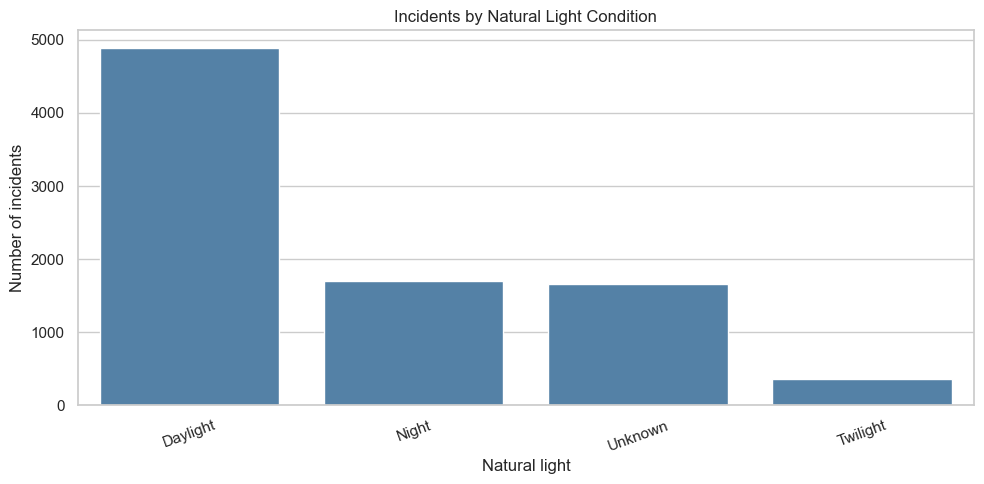

In [67]:
# -----------------------------
# 5. PLOT: NATURAL LIGHT
# -----------------------------
plt.figure(figsize=(10, 5))
sns.barplot(
    data=light_counts.head(10),
    x="natural_light",
    y="count",
    color="steelblue"
)
plt.title("Incidents by Natural Light Condition")
plt.xlabel("Natural light")
plt.ylabel("Number of incidents")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [68]:
# -----------------------------
# 6. SEA STATE DISTRIBUTION
# -----------------------------
sea_counts = (
    df["sea_state"]
    .fillna("Missing")
    .value_counts()
    .reset_index()
)
sea_counts.columns = ["sea_state", "count"]
sea_counts["pct"] = (sea_counts["count"] / len(df)) * 100

print("\n===== TOP SEA STATE CATEGORIES =====")
print(sea_counts.head(15))


===== TOP SEA STATE CATEGORIES =====
                         sea_state  count        pct
0                          Unknown   3767  43.807419
1      3 - Slight - (0.5 - 1.25 m)   1312  15.257588
2       2 - Smooth - (0.1 - 0.5 m)   1055  12.268868
3   1 - Calm rippled - (0 - 0.1 m)    893  10.384928
4    4 - Moderate - (1.25 - 2.5 m)    773   8.989417
5          0 - Calm glassy - (0 m)    479   5.570415
6          5 - Rough - (2.5 - 4 m)    240   2.791022
7   6 - Very rough - (4.0 - 6.0 m)     56   0.651239
8         7 - High - (6.0 - 9.0 m)     16   0.186068
9   8 - Very High - (9.0 - 14.0 m)      6   0.069776
10                      Unknown SS      2   0.023259


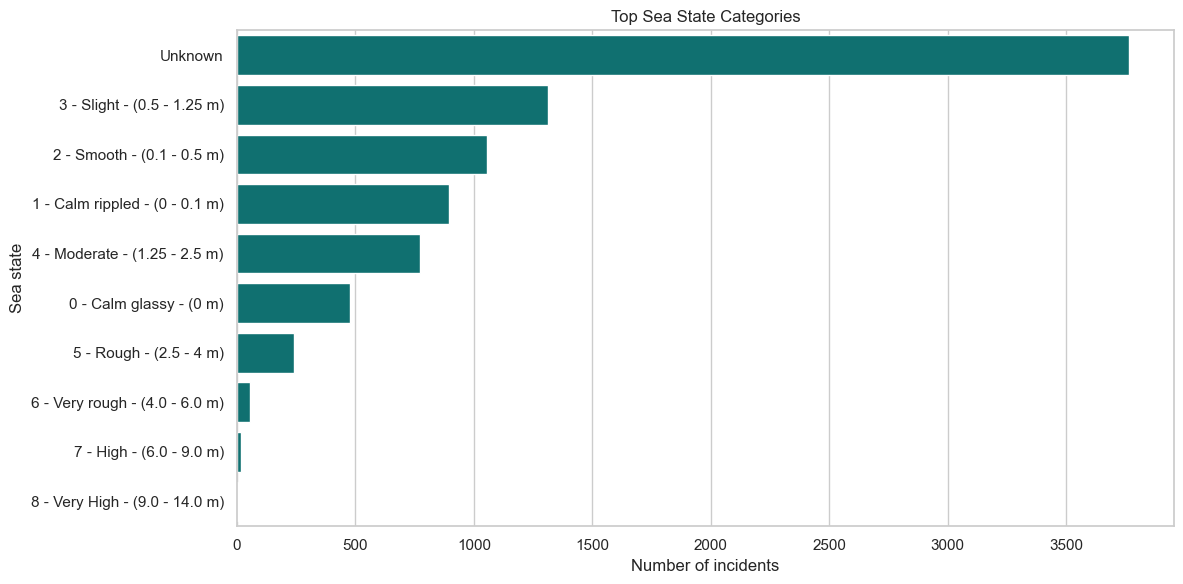

In [69]:
# -----------------------------
# 7. PLOT: SEA STATE
# -----------------------------
plt.figure(figsize=(12, 6))
sns.barplot(
    data=sea_counts.head(10),
    y="sea_state",
    x="count",
    color="teal"
)
plt.title("Top Sea State Categories")
plt.xlabel("Number of incidents")
plt.ylabel("Sea state")
plt.tight_layout()
plt.show()

In [70]:
# -----------------------------
# FIX VISIBILITY LABELS FOR PLOTTING
# -----------------------------
df["visibility_plot"] = df["visibility"].astype("string").str.strip()

df["visibility_plot"] = df["visibility_plot"].replace({
    "<NA>": pd.NA,
    "NA": pd.NA,
    "N/A": pd.NA,
    "nan": pd.NA,
    "": pd.NA,

    "Unknown": "Unknown",
    "unknown": "Unknown",
    "UNKNOWN": "Unknown",
    "Unknown Vis": "Unknown",
    "Unknown visibility": "Unknown",
    "Unknown Visibility": "Unknown",
    "Unknown vis": "Unknown",
    "Visibility Unknown": "Unknown"
})

df["visibility_plot"] = df["visibility_plot"].fillna("Missing")
print(sorted(df["visibility"].dropna().unique()))
print(sorted(df["visibility_plot"].dropna().unique()))

['Good - 5.0 <= Vis < 25.0 nm', 'Moderate - 2.0 <=Vis < 5.0 nm', 'Poor - 0.5 <=Vis < 2.0 nm', 'Unknown', 'Unknown Vis', 'Very good - Vis >= 25.0 nm', 'Very poor - Vis < 0.5 nm']
['Good - 5.0 <= Vis < 25.0 nm', 'Moderate - 2.0 <=Vis < 5.0 nm', 'Poor - 0.5 <=Vis < 2.0 nm', 'Unknown', 'Very good - Vis >= 25.0 nm', 'Very poor - Vis < 0.5 nm']


In [71]:
# -----------------------------
# 8. VISIBILITY DISTRIBUTION
# -----------------------------
visibility_counts = (
    df["visibility_plot"]
    .value_counts()
    .reset_index()
)
visibility_counts.columns = ["visibility", "count"]
visibility_counts["pct"] = (visibility_counts["count"] / len(df)) * 100

print("\n===== VISIBILITY DISTRIBUTION =====")
print(visibility_counts.head(15))


===== VISIBILITY DISTRIBUTION =====
                      visibility  count        pct
0                        Unknown   4125  47.970694
1    Good - 5.0 <= Vis < 25.0 nm   3156  36.701942
2     Very good - Vis >= 25.0 nm    803   9.338295
3  Moderate - 2.0 <=Vis < 5.0 nm    397   4.616816
4      Poor - 0.5 <=Vis < 2.0 nm     86   1.000116
5       Very poor - Vis < 0.5 nm     32   0.372136


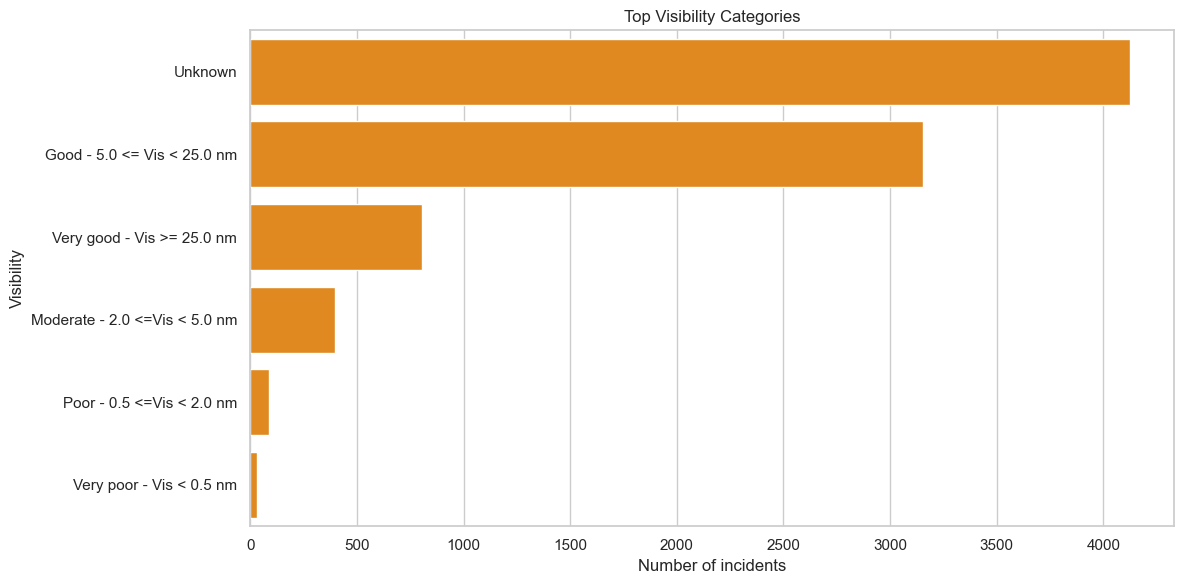

In [72]:
# -----------------------------
# 9. PLOT: VISIBILITY
# -----------------------------
plt.figure(figsize=(12, 6))
sns.barplot(
    data=visibility_counts.head(10),
    y="visibility",
    x="count",
    color="darkorange"
)
plt.title("Top Visibility Categories")
plt.xlabel("Number of incidents")
plt.ylabel("Visibility")
plt.tight_layout()
plt.show()

In [76]:
# -----------------------------
# FIX WEATHER LABELS FOR PLOTTING
# -----------------------------
df["weather_plot"] = df["weather"].astype("string").str.strip()

df["weather_plot"] = df["weather_plot"].replace({
    "<NA>": pd.NA,
    "NA": pd.NA,
    "N/A": pd.NA,
    "nan": pd.NA,
    "": pd.NA,

    "Unknown": "Unknown",
    "unknown": "Unknown",
    "UNKNOWN": "Unknown",
    "Unknown W": "Unknown",
    "Unknown Weather": "Unknown",
    "unknown weather": "Unknown"
})

df["weather_plot"] = df["weather_plot"].fillna("Missing")

In [77]:
# -----------------------------
# 10. WEATHER DISTRIBUTION
# -----------------------------
weather_counts = (
    df["weather_plot"]
    .value_counts()
    .reset_index()
)

weather_counts.columns = ["weather", "count"]
weather_counts["pct"] = (weather_counts["count"] / len(df)) * 100

print("\n===== WEATHER DISTRIBUTION =====")
print(weather_counts.head(15))


===== WEATHER DISTRIBUTION =====
    weather  count        pct
0   Unknown   4327  50.319805
1     Clear   2823  32.829399
2  Overcast    969  11.268752
3      Rain    429   4.988952
4       Fog     44   0.511687
5      Snow      7   0.081405


In [78]:
df["weather_plot"] = df["weather"].astype("string").str.strip()

df["weather_plot"] = df["weather_plot"].replace({
    "<NA>": pd.NA,
    "NA": pd.NA,
    "N/A": pd.NA,
    "nan": pd.NA,
    "": pd.NA
})

df["weather_plot"] = df["weather_plot"].str.replace(r"^Unknown.*$", "Unknown", regex=True)
df["weather_plot"] = df["weather_plot"].fillna("Missing")

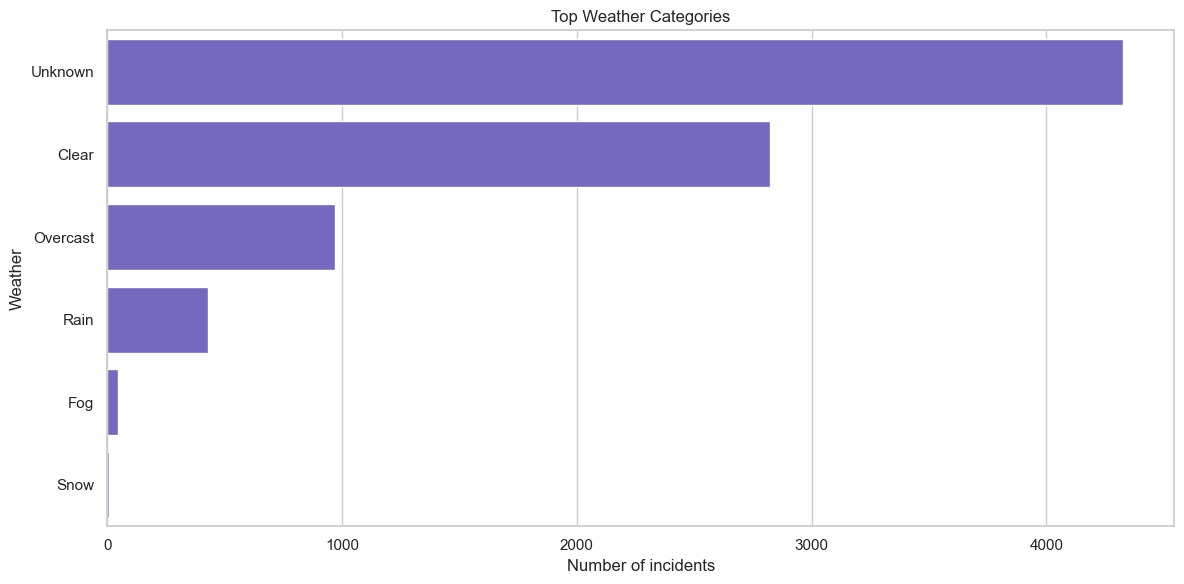

In [79]:
# -----------------------------
# 11. PLOT: WEATHER
# -----------------------------
plt.figure(figsize=(12, 6))
sns.barplot(
    data=weather_counts.head(10),
    y="weather",
    x="count",
    color="slateblue"
)
plt.title("Top Weather Categories")
plt.xlabel("Number of incidents")
plt.ylabel("Weather")
plt.tight_layout()
plt.show()

In [81]:
# -----------------------------
# FIX SEA STATE LABELS FOR PLOTTING
# -----------------------------
df["sea_state_plot"] = df["sea_state"].astype("string").str.strip()

df["sea_state_plot"] = df["sea_state_plot"].replace({
    "<NA>": pd.NA,
    "NA": pd.NA,
    "N/A": pd.NA,
    "nan": pd.NA,
    "": pd.NA,

    "Unknown": "Unknown",
    "unknown": "Unknown",
    "UNKNOWN": "Unknown",
    "Unknown SS": "Unknown",
    "Unknown Sea State": "Unknown"
})

df["sea_state_plot"] = df["sea_state_plot"].fillna("Missing")

In [82]:
# -----------------------------
# 12. SEA STATE DISTRIBUTION
# -----------------------------
sea_state_counts = (
    df["sea_state_plot"]
    .value_counts()
    .reset_index()
)

sea_state_counts.columns = ["sea_state", "count"]
sea_state_counts["pct"] = (sea_state_counts["count"] / len(df)) * 100

print("\n===== SEA STATE DISTRIBUTION =====")
print(sea_state_counts.head(15))


===== SEA STATE DISTRIBUTION =====
                        sea_state  count        pct
0                         Unknown   3769  43.830678
1     3 - Slight - (0.5 - 1.25 m)   1312  15.257588
2      2 - Smooth - (0.1 - 0.5 m)   1055  12.268868
3  1 - Calm rippled - (0 - 0.1 m)    893  10.384928
4   4 - Moderate - (1.25 - 2.5 m)    773   8.989417
5         0 - Calm glassy - (0 m)    479   5.570415
6         5 - Rough - (2.5 - 4 m)    240   2.791022
7  6 - Very rough - (4.0 - 6.0 m)     56   0.651239
8        7 - High - (6.0 - 9.0 m)     16   0.186068
9  8 - Very High - (9.0 - 14.0 m)      6   0.069776


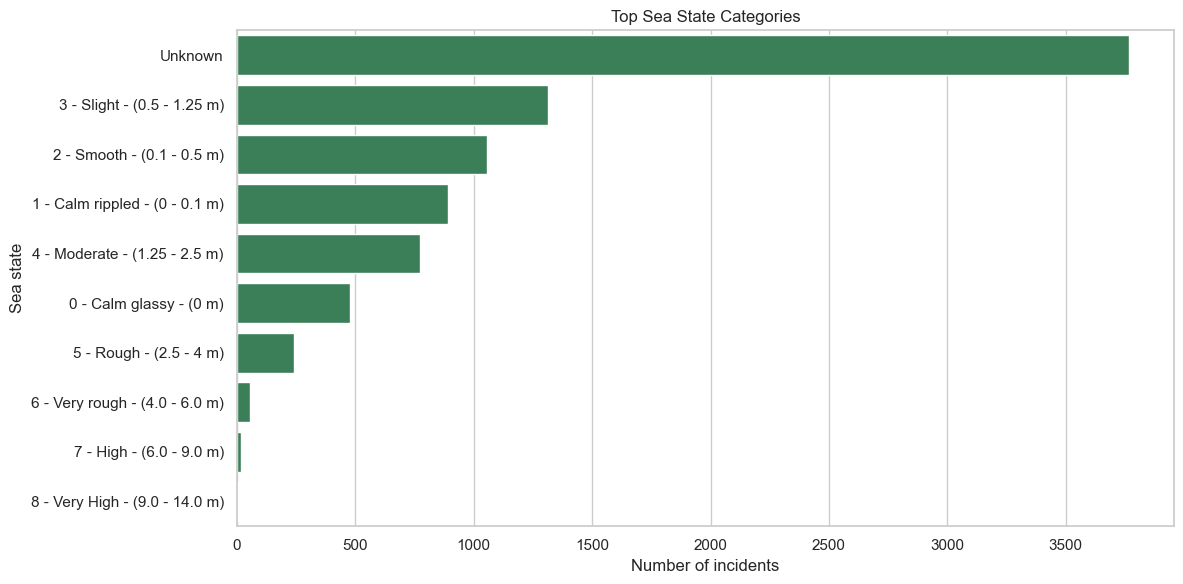

In [83]:
# -----------------------------
# 13. PLOT: SEA STATE
# -----------------------------
plt.figure(figsize=(12, 6))
sns.barplot(
    data=sea_state_counts.head(10),
    y="sea_state",
    x="count",
    color="seagreen"
)
plt.title("Top Sea State Categories")
plt.xlabel("Number of incidents")
plt.ylabel("Sea state")
plt.tight_layout()
plt.show()